In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Fase 1: Configuración y Entrono de desarrollo

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Importación de librerías
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd          # Manipulación de DataFrames
import sqlite3               # Motor de base de datos SQLite
import json                  # Parseo de columnas JSON embebidas
import ast                   # Conversión segura de strings a estructuras Python
import os                    # Manejo de rutas y archivos

print('Done')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Rutas del dataset en Kaggle
# Los archivos se encuentran en /kaggle/input/ cuando se agrega el dataset
# ─────────────────────────────────────────────────────────────────────────────
RUTA_MOVIES  = '/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv'
RUTA_CREDITS = '/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv'
RUTA_DB      = '/kaggle/working/tmdb_normalizado.db'  # Archivo de base de datos de salida

# Verificar que los archivos existen
for ruta in [RUTA_MOVIES, RUTA_CREDITS]:
    if os.path.exists(ruta):
        print(f'Encontrado: {ruta}')
    else:
        print(f'No encontrado: {ruta} — Verifica que el dataset esté agregado al notebook.')

# Fase 2: Modelado Teórico y Diseño Relacional

Crear diagrama E/R

Dos tablas CSV, una con movie credits y otra con información de película.

Se pueden juntar usando el ID de la película en ambas tablas.
ID en las dos tablas son llaves.

En *movies.csv*, genres, keywords, production company y production country tienen sus IDs.
En *credits.csv*, cast y crew tienen sus IDs.

## 2.1 Lectura y Exploración Inicial


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Lectura de los archivos CSV originales
# ─────────────────────────────────────────────────────────────────────────────
df_movies  = pd.read_csv(RUTA_MOVIES)
df_credits = pd.read_csv(RUTA_CREDITS)

print(f'Películas:  {df_movies.shape[0]} filas, {df_movies.shape[1]} columnas')
print(f'Créditos:   {df_credits.shape[0]} filas, {df_credits.shape[1]} columnas')

In [ ]:
# Vista general de las columnas del archivo de películas
print('Columnas de tmdb_5000_movies.csv:')
for col in df_movies.columns:
    print(f'  - {col}: {df_movies[col].dtype}')

In [ ]:
# Vista general de las columnas del archivo de créditos
print('Columnas de tmdb_5000_credits.csv:')
for col in df_credits.columns:
    print(f'  - {col}: {df_credits[col].dtype}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Identificación de columnas con JSON embebido
# Estas columnas contienen listas de objetos JSON como string,
# lo cual viola la 1NF (primera forma normal)
# ─────────────────────────────────────────────────────────────────────────────
columnas_json_movies  = ['genres', 'keywords', 'production_companies', 
                         'production_countries', 'spoken_languages']
columnas_json_credits = ['cast', 'crew']

print('Ejemplos de valores JSON en tmdb_5000_movies.csv:')
print()
for col in columnas_json_movies:
    print(f'>>> {col}:')
    print(df_movies[col].iloc[0][:10], '...')
    print()

In [ ]:
print('Ejemplos de valores JSON en tmdb_5000_credits.csv:')
print()
for col in columnas_json_credits:
    print(f'>>> {col}:')
    print(df_credits[col].iloc[0][:10], '...')
    print()

A mano
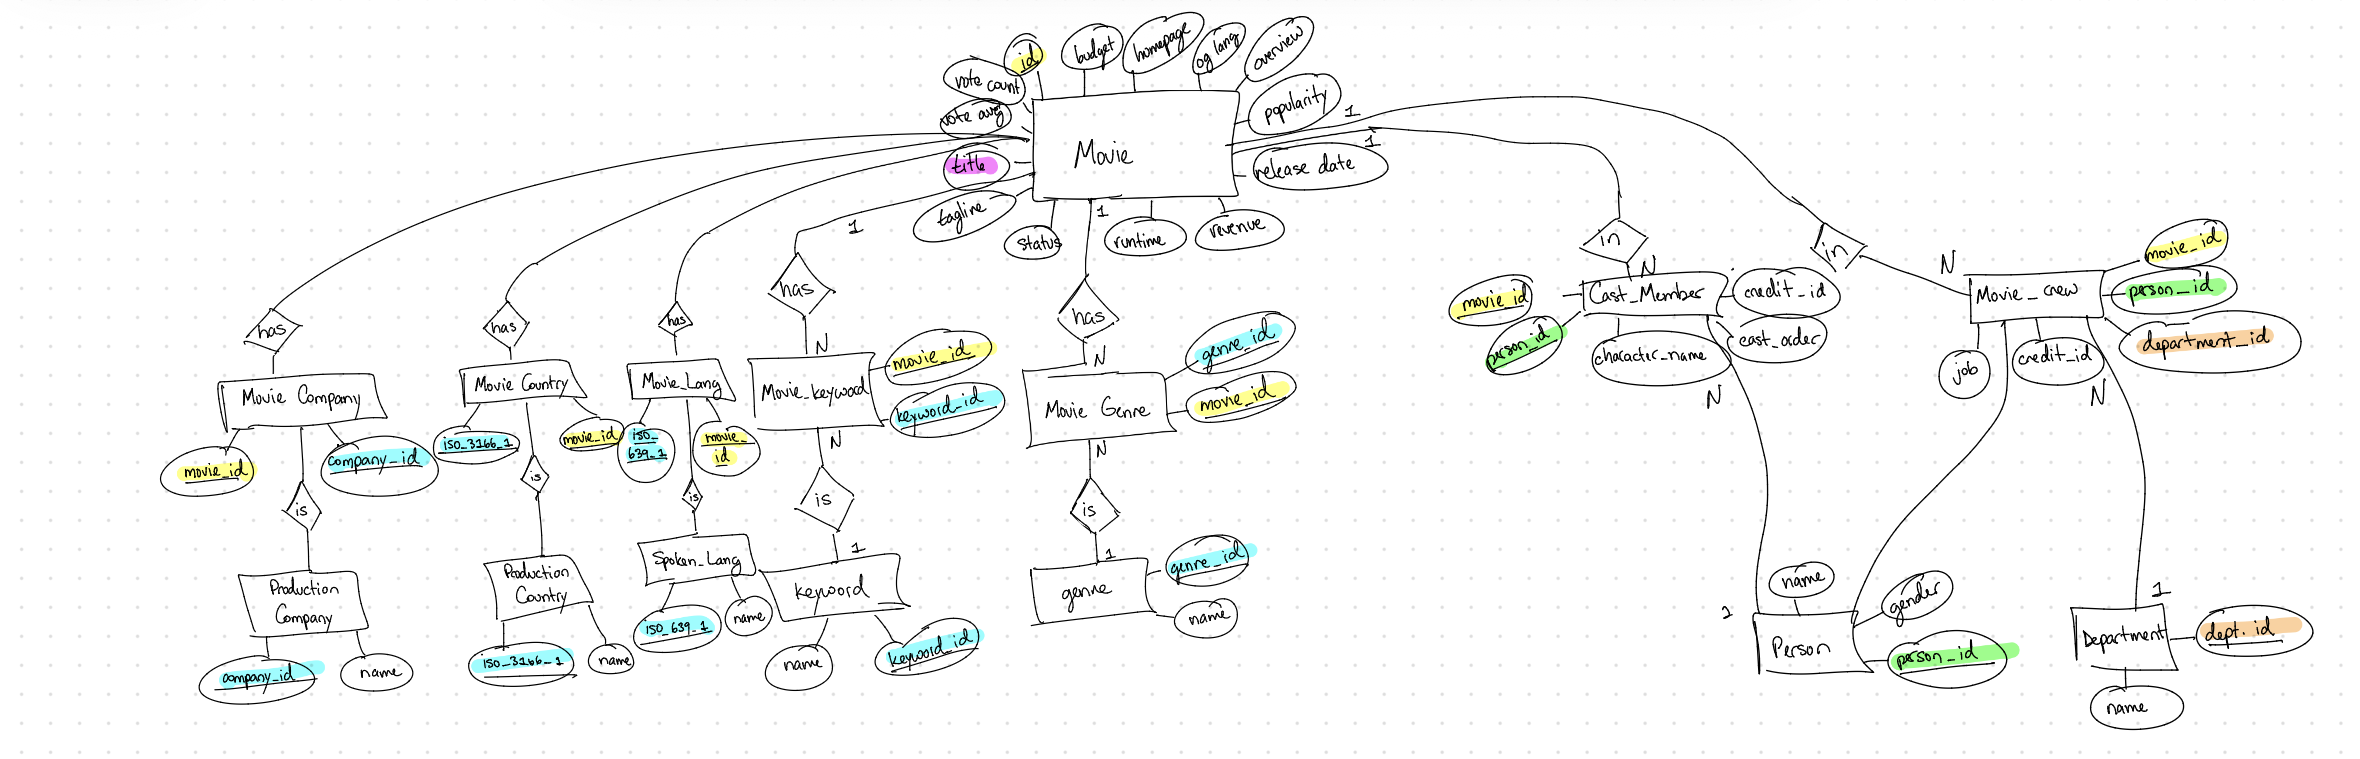

Draw.io

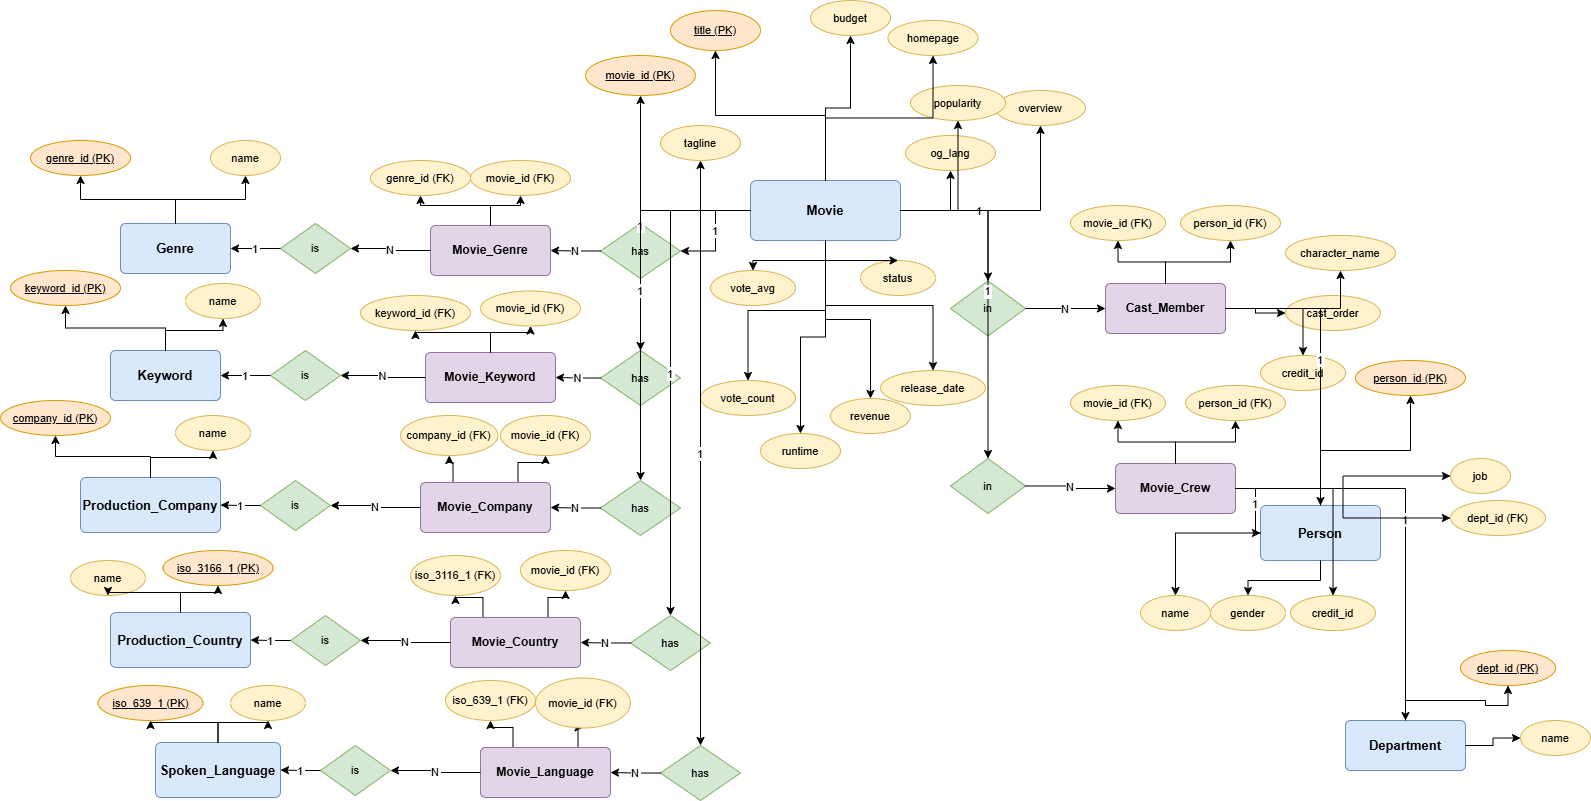

## 2.3 Proceso de Normalización Paso a Paso

### Primera Forma Normal (1NF)
**Regla:** Cada celda debe contener un único valor atómico. No se permiten grupos repetitivos ni listas.

**Problema identificado:** Las columnas `genres`, `keywords`, `production_companies`, `production_countries`, `spoken_languages`, `cast` y `crew` contienen listas JSON — múltiples valores por celda. Esto viola la 1NF.

**Solución:** Cada lista JSON se extrae a una tabla propia. Por ejemplo:

| ANTES (viola 1NF) | DESPUÉS (cumple 1NF) |
|---|---|
| `movie_id=1, genres='[{"id":28,"name":"Action"},{"id":12,"name":"Adventure"}]'` | `movie_id=1, genre_id=28` |
| | `movie_id=1, genre_id=12` |

---

### Segunda Forma Normal (2NF)
**Regla:** Cumplir 1NF y además cada atributo no-clave debe depender de la **clave primaria completa**, no de una parte de ella.

**Problema identificado:** En una tabla hipotética `Movie_Cast(movie_id, person_id, character, nombre_actor)`, el atributo `nombre_actor` depende solo de `person_id`, no de la PK compuesta `(movie_id, person_id)`.

**Solución:** Se crean tablas catálogo separadas:
- `Person(person_id, name, gender)` — atributos que dependen solo del actor
- `Movie_Cast(movie_id, person_id, character_name, cast_order, credit_id)` — atributos que dependen de la combinación película+actor
- Igual para `Genre`, `Keyword`, `Production_Company`, `Production_Country`, `Spoken_Language`

---

### Tercera Forma Normal (3NF)
**Regla:** Cumplir 2NF y además no debe haber dependencias transitivas (un atributo no-clave que dependa de otro atributo no-clave).

**Problema identificado:** En `Movie_Crew`, el campo `department` ("Directing", "Writing", etc.) es un valor repetitivo que no depende directamente de `(movie_id, person_id)` sino que es una categoría propia.

**Solución:** Se extrae `Department(department_id, name)` como tabla catálogo. `Movie_Crew` solo guarda `department_id` como FK.

---

### Forma Normal de Boyce-Codd (BCNF) y 4FN
**Regla 4NF:** No deben existir dependencias multivaluadas independientes en la misma tabla.

**Problema identificado:** Si se tuviera una tabla `Movie_Cast_Genre(movie_id, person_id, genre_id)`, se crearía una dependencia multivaluada independiente: los actores y los géneros de una película son hechos independientes entre sí — un actor no determina un género.

**Solución:** Las relaciones independientes van en tablas separadas:
- `Movie_Cast(movie_id, person_id, ...)` — independiente
- `Movie_Genre(movie_id, genre_id)` — independiente

Nunca se mezclan en una sola tabla.

## 2.4 Modelo Relacional Final

El esquema lógico resultante de la normalización es el siguiente:

```
Movie          (movie_id PK, title, budget, popularity, release_date, vote_average,
                vote_count, runtime, revenue, status, original_language,
                overview, homepage, tagline)

Genre          (genre_id PK, name)
Keyword        (keyword_id PK, name)
Production_Company (company_id PK, name)
Production_Country (iso_3166_1 PK, name)
Spoken_Language    (iso_639_1 PK, name)
Person         (person_id PK, name, gender)
Department     (department_id PK, name)

Movie_Genre    (movie_id FK, genre_id FK)                          PK compuesta
Movie_Keyword  (movie_id FK, keyword_id FK)                        PK compuesta
Movie_Company  (movie_id FK, company_id FK)                        PK compuesta
Movie_Country  (movie_id FK, iso_3166_1 FK)                        PK compuesta
Movie_Language (movie_id FK, iso_639_1 FK)                         PK compuesta
Movie_Cast     (movie_id FK, person_id FK, character_name,
                cast_order, credit_id)                              PK compuesta
Movie_Crew     (movie_id FK, person_id FK, department_id FK,
                job, credit_id)                                     PK compuesta
```

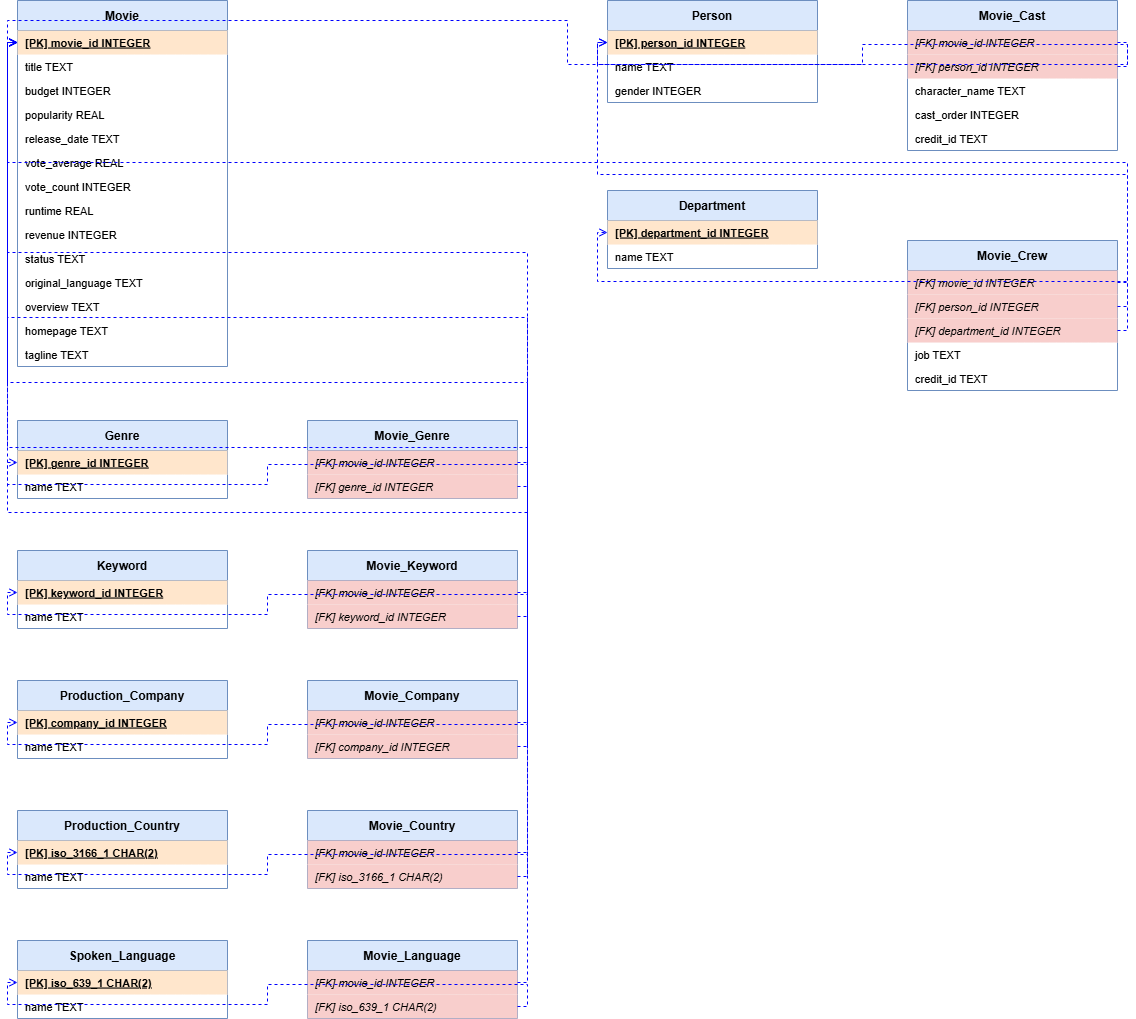

---
# Fase 3: ETL e Implementación en SQLite

## 3.1 Función auxiliar para parsear JSON

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Función de utilidad para parsear columnas JSON embebidas
# Algunas celdas pueden estar vacías o ser inválidas, por eso usamos
# un bloque try/except para retornar una lista vacía en caso de error
# ─────────────────────────────────────────────────────────────────────────────
def parsear_json(valor):
    """Convierte un string JSON embebido a una lista de diccionarios Python."""
    try:
        return ast.literal_eval(valor) if isinstance(valor, str) else []
    except (ValueError, SyntaxError):
        return []

print('Función parsear_json() definida.')

## 3.2 Extracción y Normalización — Tabla Movie (principal)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla: Movie
# Se seleccionan solo las columnas atómicas (no-JSON) del archivo de películas.
# La columna 'id' se renombra a 'movie_id' para claridad.
# ─────────────────────────────────────────────────────────────────────────────
df_movie = df_movies[[
    'id', 'title', 'budget', 'popularity', 'release_date',
    'vote_average', 'vote_count', 'runtime', 'revenue',
    'status', 'original_language', 'overview', 'homepage', 'tagline'
]].copy()

df_movie.rename(columns={'id': 'movie_id'}, inplace=True)

# Eliminar filas con movie_id nulo
df_movie.dropna(subset=['movie_id'], inplace=True)
df_movie['movie_id'] = df_movie['movie_id'].astype(int)

print(f'Tabla Movie: {df_movie.shape[0]} filas, {df_movie.shape[1]} columnas')
df_movie.head(3)

## 3.3 Extracción — Genre y Movie_Genre

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Genre y Movie_Genre
# Se parsea la columna 'genres' de cada película.
# Genre almacena los géneros únicos.
# Movie_Genre es la tabla de unión N:M entre Movie y Genre.
# ─────────────────────────────────────────────────────────────────────────────
registros_genre        = []  # Para la tabla catálogo Genre
registros_movie_genre  = []  # Para la junction table Movie_Genre

for _, fila in df_movies.iterrows():
    movie_id = fila['id']
    generos  = parsear_json(fila['genres'])
    for g in generos:
        registros_genre.append({'genre_id': g['id'], 'name': g['name']})
        registros_movie_genre.append({'movie_id': movie_id, 'genre_id': g['id']})

# Construir DataFrames y eliminar duplicados
df_genre       = pd.DataFrame(registros_genre).drop_duplicates(subset='genre_id').reset_index(drop=True)
df_movie_genre = pd.DataFrame(registros_movie_genre).drop_duplicates().reset_index(drop=True)

print(f'Tabla Genre:       {len(df_genre)} géneros únicos')
print(f'Tabla Movie_Genre: {len(df_movie_genre)} relaciones película-género')
df_genre.head(2)

## 3.4 Extracción — Keyword y Movie_Keyword

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Keyword y Movie_Keyword
# Mismo patrón que Genre — parseo de la columna 'keywords'.
# ─────────────────────────────────────────────────────────────────────────────
registros_keyword       = []
registros_movie_keyword = []

for _, fila in df_movies.iterrows():
    movie_id = fila['id']
    keywords = parsear_json(fila['keywords'])
    for k in keywords:
        registros_keyword.append({'keyword_id': k['id'], 'name': k['name']})
        registros_movie_keyword.append({'movie_id': movie_id, 'keyword_id': k['id']})

df_keyword       = pd.DataFrame(registros_keyword).drop_duplicates(subset='keyword_id').reset_index(drop=True)
df_movie_keyword = pd.DataFrame(registros_movie_keyword).drop_duplicates().reset_index(drop=True)

print(f'Tabla Keyword:       {len(df_keyword)} keywords únicos')
print(f'Tabla Movie_Keyword: {len(df_movie_keyword)} relaciones película-keyword')
df_keyword.head(2)

## 3.5 Extracción — Production_Company y Movie_Company

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Production_Company y Movie_Company
# ─────────────────────────────────────────────────────────────────────────────
registros_company       = []
registros_movie_company = []

for _, fila in df_movies.iterrows():
    movie_id  = fila['id']
    companies = parsear_json(fila['production_companies'])
    for c in companies:
        registros_company.append({'company_id': c['id'], 'name': c['name']})
        registros_movie_company.append({'movie_id': movie_id, 'company_id': c['id']})

df_company       = pd.DataFrame(registros_company).drop_duplicates(subset='company_id').reset_index(drop=True)
df_movie_company = pd.DataFrame(registros_movie_company).drop_duplicates().reset_index(drop=True)

print(f'Tabla Production_Company: {len(df_company)} compañías únicas')
print(f'Tabla Movie_Company:      {len(df_movie_company)} relaciones película-compañía')
df_company.head(2)

## 3.6 Extracción — Production_Country y Movie_Country

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Production_Country y Movie_Country
# La PK es el código ISO 3166-1 alpha-2 (ej: 'US', 'GB') — clave natural de texto
# ─────────────────────────────────────────────────────────────────────────────
registros_country       = []
registros_movie_country = []

for _, fila in df_movies.iterrows():
    movie_id  = fila['id']
    countries = parsear_json(fila['production_countries'])
    for c in countries:
        registros_country.append({'iso_3166_1': c['iso_3166_1'], 'name': c['name']})
        registros_movie_country.append({'movie_id': movie_id, 'iso_3166_1': c['iso_3166_1']})

df_country       = pd.DataFrame(registros_country).drop_duplicates(subset='iso_3166_1').reset_index(drop=True)
df_movie_country = pd.DataFrame(registros_movie_country).drop_duplicates().reset_index(drop=True)

print(f'Tabla Production_Country: {len(df_country)} países únicos')
print(f'Tabla Movie_Country:      {len(df_movie_country)} relaciones película-país')
df_country.head(2)

## 3.7 Extracción — Spoken_Language y Movie_Language

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Spoken_Language y Movie_Language
# La PK es el código ISO 639-1 (ej: 'en', 'es') — clave natural de texto
# ─────────────────────────────────────────────────────────────────────────────
registros_language       = []
registros_movie_language = []

for _, fila in df_movies.iterrows():
    movie_id  = fila['id']
    languages = parsear_json(fila['spoken_languages'])
    for l in languages:
        registros_language.append({'iso_639_1': l['iso_639_1'], 'name': l['name']})
        registros_movie_language.append({'movie_id': movie_id, 'iso_639_1': l['iso_639_1']})

df_language       = pd.DataFrame(registros_language).drop_duplicates(subset='iso_639_1').reset_index(drop=True)
df_movie_language = pd.DataFrame(registros_movie_language).drop_duplicates().reset_index(drop=True)

print(f'Tabla Spoken_Language: {len(df_language)} idiomas únicos')
print(f'Tabla Movie_Language:  {len(df_movie_language)} relaciones película-idioma')
df_language.head(2)

## 3.8 Extracción — Person, Department, Movie_Cast y Movie_Crew

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Person y Movie_Cast
# Person es una tabla compartida para actores y crew (mismo person_id de TMDB).
# Movie_Cast almacena el rol específico del actor en cada película.
# ─────────────────────────────────────────────────────────────────────────────
registros_person     = []
registros_movie_cast = []

for _, fila in df_credits.iterrows():
    movie_id = fila['movie_id']
    cast     = parsear_json(fila['cast'])
    for actor in cast:
        # Datos de la persona (tabla Person)
        registros_person.append({
            'person_id': actor['id'],
            'name':      actor['name'],
            'gender':    actor.get('gender', 0)
        })
        # Datos del rol (tabla Movie_Cast)
        registros_movie_cast.append({
            'movie_id':       movie_id,
            'person_id':      actor['id'],
            'character_name': actor.get('character', ''),
            'cast_order':     actor.get('order', 0),
            'credit_id':      actor.get('credit_id', '')
        })

df_person     = pd.DataFrame(registros_person)
df_movie_cast = pd.DataFrame(registros_movie_cast).drop_duplicates(subset=['movie_id', 'person_id']).reset_index(drop=True)

print(f'Personas (desde cast):  {len(df_person)} registros')
print(f'Tabla Movie_Cast:       {len(df_movie_cast)} relaciones película-actor')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Tablas: Department y Movie_Crew
# Department se extrae como catálogo independiente (aplica 3NF).
# Movie_Crew almacena el trabajo específico de cada persona en cada película.
# ─────────────────────────────────────────────────────────────────────────────
registros_department = []
registros_movie_crew = []

for _, fila in df_credits.iterrows():
    movie_id = fila['movie_id']
    crew     = parsear_json(fila['crew'])
    for miembro in crew:
        dept_name = miembro.get('department', 'Unknown')
        # Datos de la persona (se agrega a la misma lista de Person)
        registros_person.append({
            'person_id': miembro['id'],
            'name':      miembro['name'],
            'gender':    miembro.get('gender', 0)
        })
        registros_department.append({'name': dept_name})
        registros_movie_crew.append({
            'movie_id':    movie_id,
            'person_id':   miembro['id'],
            'dept_name':   dept_name,          # Temporal, luego reemplazamos por dept_id
            'job':         miembro.get('job', ''),
            'credit_id':   miembro.get('credit_id', '')
        })

# Construir tabla Department con IDs únicos
df_department = (
    pd.DataFrame(registros_department)
    .drop_duplicates(subset='name')
    .reset_index(drop=True)
)
df_department.index.name = 'department_id'
df_department = df_department.reset_index()
df_department['department_id'] = df_department['department_id'] + 1  # IDs desde 1

# Construir tabla Person unificada (cast + crew) sin duplicados
df_person = (
    pd.DataFrame(registros_person)
    .drop_duplicates(subset='person_id')
    .reset_index(drop=True)
)

# Mapear nombre de departamento a department_id en Movie_Crew
dept_map = dict(zip(df_department['name'], df_department['department_id']))
df_movie_crew = pd.DataFrame(registros_movie_crew)
df_movie_crew['department_id'] = df_movie_crew['dept_name'].map(dept_map)
df_movie_crew.drop(columns=['dept_name'], inplace=True)
df_movie_crew = df_movie_crew.drop_duplicates(subset=['movie_id', 'person_id', 'credit_id']).reset_index(drop=True)

print(f'Tabla Person:      {len(df_person)} personas únicas (actores + crew)')
print(f'Tabla Department:  {len(df_department)} departamentos únicos')
print(f'Tabla Movie_Crew:  {len(df_movie_crew)} relaciones película-crew')
df_department.head(3)

## 3.9 Resumen de DataFrames normalizados

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Resumen de todas las tablas generadas por el proceso ETL
# ─────────────────────────────────────────────────────────────────────────────
tablas = {
    'Movie':               df_movie,
    'Genre':               df_genre,
    'Keyword':             df_keyword,
    'Production_Company':  df_company,
    'Production_Country':  df_country,
    'Spoken_Language':     df_language,
    'Person':              df_person,
    'Department':          df_department,
    'Movie_Genre':         df_movie_genre,
    'Movie_Keyword':       df_movie_keyword,
    'Movie_Company':       df_movie_company,
    'Movie_Country':       df_movie_country,
    'Movie_Language':      df_movie_language,
    'Movie_Cast':          df_movie_cast,
    'Movie_Crew':          df_movie_crew,
}

print(f'{"Tabla":<25} {"Filas":>8} {"Columnas":>10}')
print('-' * 47)
for nombre, df in tablas.items():
    print(f'{nombre:<25} {len(df):>8} {len(df.columns):>10}')

## 3.10 Creación de la Base de Datos SQLite

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Creación del esquema SQL con llaves primarias y foráneas explícitas
# SQLite soporta FK pero no las enforcea por defecto;
# se activan con PRAGMA foreign_keys = ON
# ─────────────────────────────────────────────────────────────────────────────
DDL = """
PRAGMA foreign_keys = ON;

CREATE TABLE IF NOT EXISTS Movie (
    movie_id          INTEGER PRIMARY KEY,
    title             TEXT,
    budget            INTEGER,
    popularity        REAL,
    release_date      TEXT,
    vote_average      REAL,
    vote_count        INTEGER,
    runtime           REAL,
    revenue           INTEGER,
    status            TEXT,
    original_language TEXT,
    overview          TEXT,
    homepage          TEXT,
    tagline           TEXT
);

CREATE TABLE IF NOT EXISTS Genre (
    genre_id INTEGER PRIMARY KEY,
    name     TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Keyword (
    keyword_id INTEGER PRIMARY KEY,
    name       TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Production_Company (
    company_id INTEGER PRIMARY KEY,
    name       TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Production_Country (
    iso_3166_1 CHAR(2) PRIMARY KEY,
    name       TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Spoken_Language (
    iso_639_1 CHAR(2) PRIMARY KEY,
    name      TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Person (
    person_id INTEGER PRIMARY KEY,
    name      TEXT NOT NULL,
    gender    INTEGER
);

CREATE TABLE IF NOT EXISTS Department (
    department_id INTEGER PRIMARY KEY,
    name          TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS Movie_Genre (
    movie_id INTEGER REFERENCES Movie(movie_id),
    genre_id INTEGER REFERENCES Genre(genre_id),
    PRIMARY KEY (movie_id, genre_id)
);

CREATE TABLE IF NOT EXISTS Movie_Keyword (
    movie_id   INTEGER REFERENCES Movie(movie_id),
    keyword_id INTEGER REFERENCES Keyword(keyword_id),
    PRIMARY KEY (movie_id, keyword_id)
);

CREATE TABLE IF NOT EXISTS Movie_Company (
    movie_id   INTEGER REFERENCES Movie(movie_id),
    company_id INTEGER REFERENCES Production_Company(company_id),
    PRIMARY KEY (movie_id, company_id)
);

CREATE TABLE IF NOT EXISTS Movie_Country (
    movie_id   INTEGER REFERENCES Movie(movie_id),
    iso_3166_1 CHAR(2) REFERENCES Production_Country(iso_3166_1),
    PRIMARY KEY (movie_id, iso_3166_1)
);

CREATE TABLE IF NOT EXISTS Movie_Language (
    movie_id  INTEGER REFERENCES Movie(movie_id),
    iso_639_1 CHAR(2) REFERENCES Spoken_Language(iso_639_1),
    PRIMARY KEY (movie_id, iso_639_1)
);

CREATE TABLE IF NOT EXISTS Movie_Cast (
    movie_id       INTEGER REFERENCES Movie(movie_id),
    person_id      INTEGER REFERENCES Person(person_id),
    character_name TEXT,
    cast_order     INTEGER,
    credit_id      TEXT,
    PRIMARY KEY (movie_id, person_id)
);

CREATE TABLE IF NOT EXISTS Movie_Crew (
    movie_id      INTEGER REFERENCES Movie(movie_id),
    person_id     INTEGER REFERENCES Person(person_id),
    department_id INTEGER REFERENCES Department(department_id),
    job           TEXT,
    credit_id     TEXT,
    PRIMARY KEY (movie_id, person_id, credit_id)
);
"""

print('DDL definido correctamente.')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Crear la base de datos y ejecutar el DDL
# ─────────────────────────────────────────────────────────────────────────────
conn = sqlite3.connect(RUTA_DB)
cursor = conn.cursor()

# Ejecutar cada sentencia DDL por separado
for sentencia in DDL.strip().split(';'):
    sentencia = sentencia.strip()
    if sentencia:
        cursor.execute(sentencia)

conn.commit()
print(f'Base de datos creada en: {RUTA_DB}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Carga de datos (LOAD) — insertar los DataFrames normalizados en SQLite
# Se usa if_exists='append' para respetar las restricciones FK ya definidas
# El orden de inserción respeta las dependencias: primero tablas padre, luego hijas
# ─────────────────────────────────────────────────────────────────────────────
orden_carga = [
    ('Movie',               df_movie,          'movie_id'),
    ('Genre',               df_genre,           'genre_id'),
    ('Keyword',             df_keyword,         'keyword_id'),
    ('Production_Company',  df_company,         'company_id'),
    ('Production_Country',  df_country,         'iso_3166_1'),
    ('Spoken_Language',     df_language,        'iso_639_1'),
    ('Person',              df_person,          'person_id'),
    ('Department',          df_department,      'department_id'),
    ('Movie_Genre',         df_movie_genre,     None),
    ('Movie_Keyword',       df_movie_keyword,   None),
    ('Movie_Company',       df_movie_company,   None),
    ('Movie_Country',       df_movie_country,   None),
    ('Movie_Language',      df_movie_language,  None),
    ('Movie_Cast',          df_movie_cast,      None),
    ('Movie_Crew',          df_movie_crew,      None),
]

for nombre_tabla, df, _ in orden_carga:
    df.to_sql(nombre_tabla, conn, if_exists='append', index=False)
    print(f'  {nombre_tabla:<25} {len(df):>6} filas insertadas')

conn.commit()
print('\n¡Carga completa!')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Verificación de integridad — confirmar que todas las tablas tienen datos
# ─────────────────────────────────────────────────────────────────────────────
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
tablas_db = [row[0] for row in cursor.fetchall()]

print(f'{'Tabla':<25} {'Filas en BD':>12}')
print('-' * 40)
for tabla in tablas_db:
    cursor.execute(f'SELECT COUNT(*) FROM "{tabla}"')
    count = cursor.fetchone()[0]
    print(f'{tabla:<25} {count:>12}')

---
# Fase 4: Consultas SQL 

Función auxiliar para ejecutar consultas y mostrar resultados como DataFrame:

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Función de utilidad para ejecutar consultas SQL y mostrar resultados
# ─────────────────────────────────────────────────────────────────────────────
def ejecutar_consulta(sql, params=None):
    """Ejecuta una consulta SQL y retorna el resultado como DataFrame."""
    if params:
        return pd.read_sql_query(sql, conn, params=params)
    return pd.read_sql_query(sql, conn)

print('Función ejecutar_consulta() definida.')

## 4.1 Búsqueda por Palabra Clave
Retorna una tabla con Título, Género, Idiomas, Popularidad y Cast para películas que contengan la palabra en el título. Máximo 15 filas.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSULTA 1: Búsqueda por palabra clave en el título
# NOTA: SQLite no soporta ORDER BY dentro de GROUP_CONCAT (es sintaxis MySQL).
# El cast se filtra por cast_order < 3 antes del JOIN para mostrar los 
# protagonistas, y se concatenan sin ordenamiento explícito interno.
# ─────────────────────────────────────────────────────────────────────────────
PALABRA_CLAVE = 'Avatar'  # ← Cambia esta palabra para probar

sql_busqueda = """
SELECT
    m.title                                    AS Titulo,
    GROUP_CONCAT(DISTINCT g.name)              AS Generos,
    GROUP_CONCAT(DISTINCT sl.name)             AS Idiomas,
    ROUND(m.popularity, 2)                     AS Popularidad,
    GROUP_CONCAT(DISTINCT p.name || ' (' || mc.character_name || ')')
                                               AS Cast_Principal
FROM Movie m
LEFT JOIN Movie_Genre    mg  ON m.movie_id = mg.movie_id
LEFT JOIN Genre           g  ON mg.genre_id = g.genre_id
LEFT JOIN Movie_Language  ml ON m.movie_id = ml.movie_id
LEFT JOIN Spoken_Language sl ON ml.iso_639_1 = sl.iso_639_1
LEFT JOIN Movie_Cast      mc ON m.movie_id = mc.movie_id AND mc.cast_order < 3
LEFT JOIN Person           p ON mc.person_id = p.person_id
WHERE m.title LIKE :patron
GROUP BY m.movie_id
ORDER BY m.popularity DESC
LIMIT 15;
"""

resultado_busqueda = ejecutar_consulta(sql_busqueda, params={'patron': f'%{PALABRA_CLAVE}%'})
print(f'Resultados para "{PALABRA_CLAVE}": {len(resultado_busqueda)} película(s) encontrada(s)')
resultado_busqueda

## 4.2 Filtro Cronológico
Muestra películas estrenadas en un año o posteriores, ordenadas ascendentemente por año y luego alfabéticamente. Máximo 15 filas.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSULTA 2: Filtro cronológico
# Muestra películas estrenadas a partir del año indicado.
# Se usa strftime para extraer el año del campo release_date (formato YYYY-MM-DD)
# ─────────────────────────────────────────────────────────────────────────────
ANNO_DESDE = 2015  # ← Cambia este año para probar

sql_cronologico = """
SELECT
    m.title                                AS Titulo,
    CAST(strftime('%Y', m.release_date) AS INTEGER) AS Anno,
    ROUND(m.popularity, 2)                 AS Popularidad,
    ROUND(m.vote_average, 1)               AS Promedio_Votos,
    GROUP_CONCAT(DISTINCT g.name)          AS Generos
FROM Movie m
LEFT JOIN Movie_Genre mg ON m.movie_id = mg.movie_id
LEFT JOIN Genre        g ON mg.genre_id = g.genre_id
WHERE CAST(strftime('%Y', m.release_date) AS INTEGER) >= :anno
  AND m.release_date IS NOT NULL
GROUP BY m.movie_id
ORDER BY Anno ASC, m.title ASC
LIMIT 15;
"""

resultado_cronologico = ejecutar_consulta(sql_cronologico, params={'anno': ANNO_DESDE})
print(f'Películas desde {ANNO_DESDE}: {len(resultado_cronologico)} resultado(s)')
resultado_cronologico

## 4.3 Métricas por Género
Número de películas y promedio de votos por género. Solo géneros con popularidad promedio ≥ 6, ordenados de mayor a menor popularidad. Máximo 10 filas.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSULTA 3: Métricas por Género
# Se agrupa por género para obtener:
#   - Número de películas en ese género
#   - Promedio de votos
#   - Popularidad promedio
# El HAVING filtra géneros con popularidad promedio >= 6
# ─────────────────────────────────────────────────────────────────────────────
sql_metricas_genero = """
SELECT
    g.name                          AS Genero,
    COUNT(DISTINCT mg.movie_id)     AS Num_Peliculas,
    ROUND(AVG(m.vote_average), 2)   AS Promedio_Votos,
    ROUND(AVG(m.popularity), 2)     AS Popularidad_Promedio
FROM Genre g
JOIN Movie_Genre mg ON g.genre_id = mg.genre_id
JOIN Movie       m  ON mg.movie_id = m.movie_id
GROUP BY g.genre_id, g.name
HAVING AVG(m.popularity) >= 6
ORDER BY Popularidad_Promedio DESC
LIMIT 10;
"""

resultado_genero = ejecutar_consulta(sql_metricas_genero)
print(f'Géneros con popularidad promedio ≥ 6: {len(resultado_genero)}')
resultado_genero

## 4.4 Métricas por Año
Mismo análisis estadístico que la consulta anterior, pero agrupado por año de estreno.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSULTA 4: Métricas por Año
# Mismo análisis que por género pero agrupando por año de estreno.
# Se extrae el año con strftime('%Y', release_date)
# ─────────────────────────────────────────────────────────────────────────────
sql_metricas_anno = """
SELECT
    CAST(strftime('%Y', m.release_date) AS INTEGER) AS Anno,
    COUNT(m.movie_id)                               AS Num_Peliculas,
    ROUND(AVG(m.vote_average), 2)                   AS Promedio_Votos,
    ROUND(AVG(m.popularity),   2)                   AS Popularidad_Promedio
FROM Movie m
WHERE m.release_date IS NOT NULL
GROUP BY Anno
HAVING AVG(m.popularity) >= 6
ORDER BY Popularidad_Promedio DESC
LIMIT 10;
"""

resultado_anno = ejecutar_consulta(sql_metricas_anno)
print(f'Años con popularidad promedio ≥ 6: {len(resultado_anno)}')
resultado_anno

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cierre de la conexión a la base de datos
# ─────────────────────────────────────────────────────────────────────────────
conn.close()
print(f'Conexión cerrada.')
print(f'Base de datos guardada en: {RUTA_DB}')
print(f'Tamaño del archivo: {os.path.getsize(RUTA_DB) / 1024 / 1024:.2f} MB')